In [1]:
import skimage
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from deepcell.applications import Mesmer
from deepcell.utils.plot_utils import create_rgb_image, make_outline_overlay
import seaborn as sb
from tqdm import tqdm
import os

In [2]:
image_folder = '/lustre/groups/luckylab/datasets/SCHEMA/CODEX/Schuerch_2020/TMA_A_bestFocus/reshaped/'

In [3]:
def normalize(image):
    image = image.astype(np.float64)
    x01 = np.percentile(image, 1)
    x99 = np.percentile(image, 99)
    if x99 - x01 > 1e-3:
        #image[image<x01] = 0
        #image -= x01 
        image /= (x99 - x01)
        image = np.clip(image,a_min=0, a_max=None)
    else:
        image[:] = 0
    return image

def rescale_255(image):
    return ((image-np.min(image))/(np.max(image) - np.min(image)))*255

def normalize_rescale(image):
    image = normalize(image)
    return rescale_255(image)

In [4]:
app = Mesmer()

2026-03-31 13:23:50.629262: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1953] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-03-31 13:23:50.631248: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 13:23:50.638722: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1953] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-03-31 13:23:50.957792: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/

In [5]:
img = skimage.io.imread(os.path.join(image_folder, "reg001_X01_Y01_Z11.ome.tiff"))

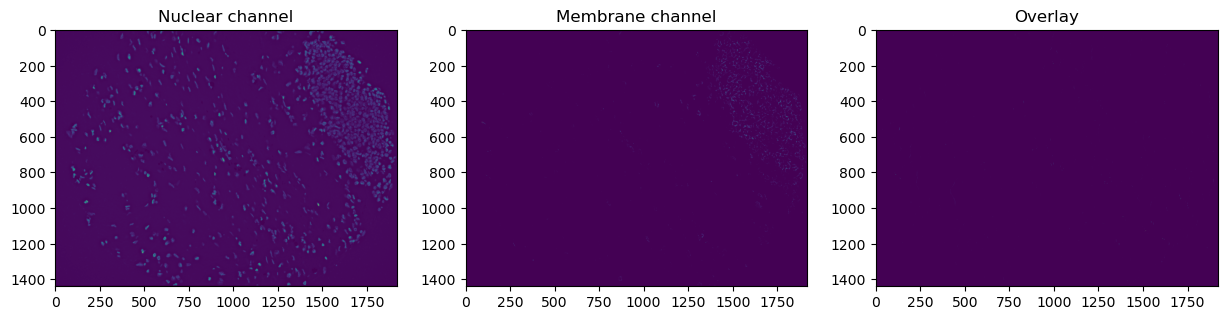

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 15))
ax[0].imshow(img[91, :, :])
ax[1].imshow(img[13, :, :])
ax[2].imshow(img[33, :, :])

ax[0].set_title('Nuclear channel')
ax[1].set_title('Membrane channel')
ax[2].set_title('Overlay')

plt.show()

### Segment one image with gaussian noise

In [7]:
gaussian_img = np.zeros((92, 1440, 1920))
for i in range(92):
    gaussian_img[i] = skimage.util.random_noise(img[i], mode='gaussian', mean=0.003, var=0.002)

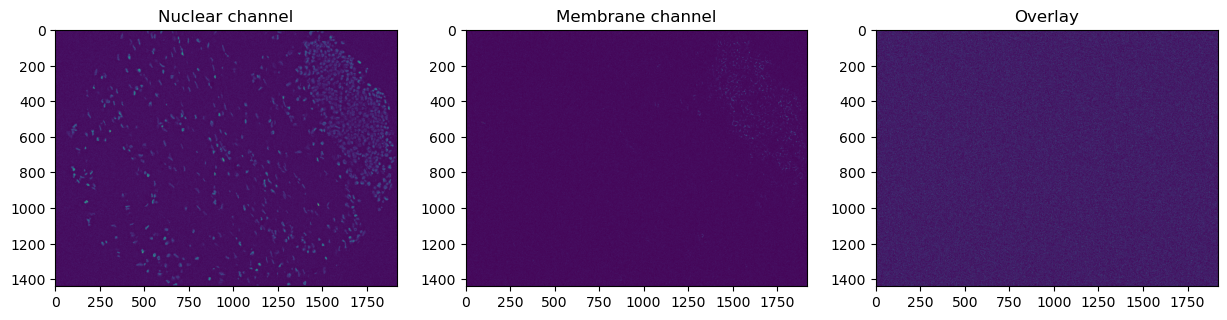

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 15))
ax[0].imshow(gaussian_img[91, :, :]) 
ax[1].imshow(gaussian_img[13, :, :])
ax[2].imshow(gaussian_img[33, :, :])

ax[0].set_title('Nuclear channel')
ax[1].set_title('Membrane channel')
ax[2].set_title('Overlay')

plt.show()

In [11]:
img_memb = np.stack((gaussian_img[33], 
                     gaussian_img[15], 
                     gaussian_img[5], 
                     gaussian_img[13], 
                     gaussian_img[37], 
                     gaussian_img[29]),axis=0) #nak, beta-cat, cd44, 45, cytok, viment
img_memb = np.max(img_memb, axis=0)
img_dapi = normalize_rescale(gaussian_img[91])
img_cp = np.stack((img_dapi, img_memb),axis=0)


In [12]:
segmentation_predictions = app.predict(np.transpose(img_cp, (1,2,0))[np.newaxis, ...], image_mpp=0.377)

2026-03-31 13:27:22.052757: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8907
2026-03-31 13:27:22.423355: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [13]:
rgb_images = create_rgb_image(np.transpose(img_cp, (1,2,0))[np.newaxis, ...], channel_colors=['green', 'blue'])
overlay_data = make_outline_overlay(rgb_data=rgb_images, predictions=segmentation_predictions)

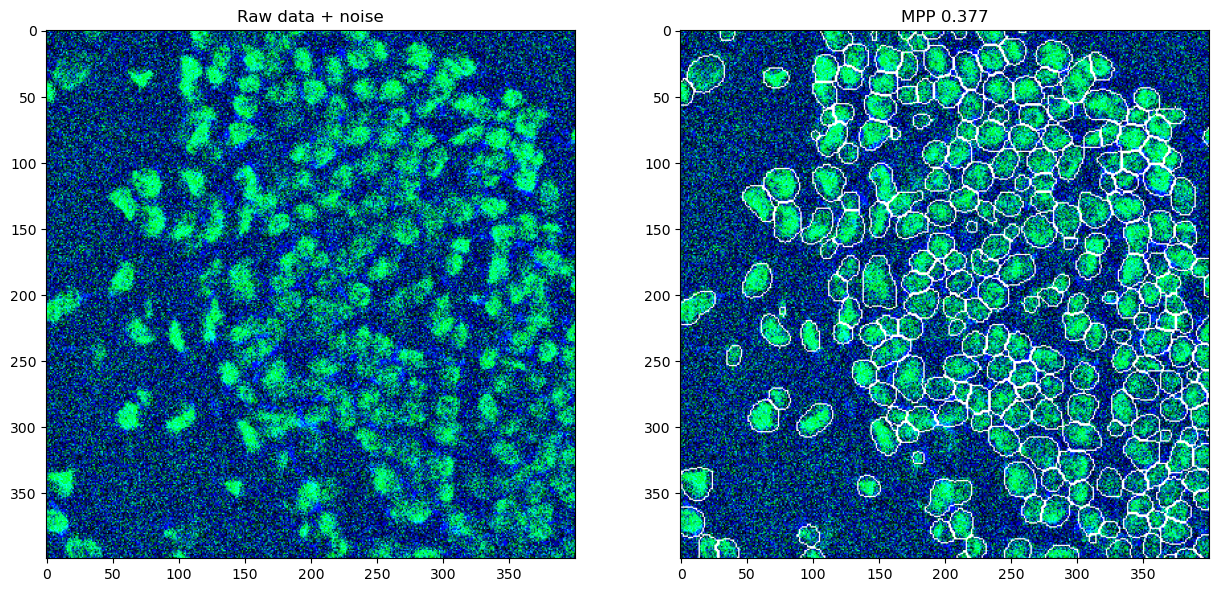

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(rgb_images[0, 100:500, 1300:1700])
ax[1].imshow(overlay_data[0, 100:500, 1300:1700])
ax[0].set_title('Raw data + noise')
ax[1].set_title('MPP 0.377')
plt.show()

### Same image, not altered

In [16]:
img_memb = np.stack((img[33], img[15], img[5], img[13], img[37], img[29]),axis=0)
img_memb = np.max(img_memb, axis=0)
img_dapi = normalize_rescale(img[91])
img_cp = np.stack((img_dapi, img_memb),axis=0)

In [17]:
segmentation_predictions = app.predict(np.transpose(img_cp, (1,2,0))[np.newaxis, ...], image_mpp=0.377)

In [18]:
rgb_images = create_rgb_image(np.transpose(img_cp, (1,2,0))[np.newaxis, ...], channel_colors=['green', 'blue'])
overlay_data = make_outline_overlay(rgb_data=rgb_images, predictions=segmentation_predictions)

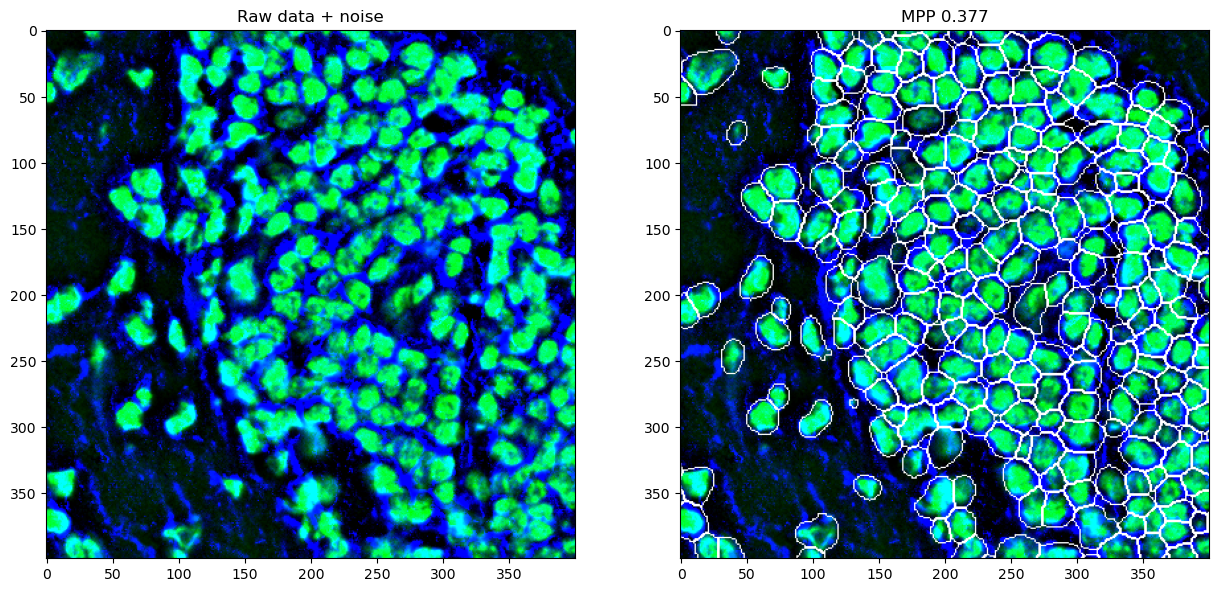

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(rgb_images[0, 100:500, 1300:1700])
ax[1].imshow(overlay_data[0, 100:500, 1300:1700])
ax[0].set_title('Raw data + noise')
ax[1].set_title('MPP 0.377')
plt.show()

### Generate original + segmentations for TTA

In [ ]:
for img_file in tqdm(os.listdir(image_folder)):
    base_name = img_file.split('.')[0]
    img = skimage.io.imread(os.path.join(image_folder, img_file))
    img_memb = np.stack((img[33], img[15], img[5], img[13], img[37], img[29]),axis=0) #nak, beta-cat, cd44, 45, cytok, viment
    img_memb = np.max(img_memb, axis=0)
    img_dapi = normalize_rescale(img[91])
    img_cp = np.stack((img_dapi, img_memb),axis=0)
    segmentation_predictions = app.predict(np.transpose(img_cp, (1,2,0))[np.newaxis, ...], image_mpp=0.377)
    skimage.io.imsave(f'mesmer_segmentations_normal/{base_name}.png', segmentation_predictions[0,...,0])

    img_90 = skimage.transform.rotate(img_cp, 90)
    segmentation_predictions = app.predict(np.transpose(img_90, (1,2,0))[np.newaxis, ...], image_mpp=0.377)
    skimage.io.imsave(f'mesmer_segmentations_rot90/{base_name}.png', segmentation_predictions[0,...,0])
    
    img_180 = skimage.transform.rotate(img_cp, 180)
    segmentation_predictions = app.predict(np.transpose(img_180, (1,2,0))[np.newaxis, ...], image_mpp=0.377)
    skimage.io.imsave(f'mesmer_segmentations_rot180/{base_name}.png', segmentation_predictions[0,...,0])

    img_270 = skimage.transform.rotate(img_cp, 270)
    segmentation_predictions = app.predict(np.transpose(img_270, (1,2,0))[np.newaxis, ...], image_mpp=0.377)
    skimage.io.imsave(f'mesmer_segmentations_rot270/{base_name}.png', segmentation_predictions[0,...,0])

    img_hflip = img_cp[:, ::-1, :]
    segmentation_predictions = app.predict(np.transpose(img_hflip, (1,2,0))[np.newaxis, ...], image_mpp=0.377)
    skimage.io.imsave(f'mesmer_segmentations_hf/{base_name}.png', segmentation_predictions[0,...,0])

    img_vflip = img_cp[::-1, :, :]
    segmentation_predictions = app.predict(np.transpose(img_vflip, (1,2,0))[np.newaxis, ...], image_mpp=0.377)
    skimage.io.imsave(f'mesmer_segmentations_vf/{base_name}.png', segmentation_predictions[0,...,0])